In [11]:
# Provides support for numerical computations and multi-dimensional arrays.
import numpy as np  

# Offers powerful data manipulation and analysis tools using DataFrames.
import pandas as pd  


# Enables creation of static, interactive, and animated visualizations in Python.
import matplotlib.pyplot as plt  

# Allows custom colormap creation for matplotlib plots.
from matplotlib.colors import LinearSegmentedColormap  

# Simplifies statistical data visualization and integrates seamlessly with matplotlib.
import seaborn as sns  


# Facilitates creation of interactive visualizations and dashboards using Plotly.
import plotly.graph_objects as go  

# Offers high-level interface for creating interactive Plotly visualizations quickly.
import plotly.express as px  

# Provides tools for arranging multiple subplots in Plotly visualizations.
import plotly.subplots as sp  

# Simplifies the creation of complex subplot layouts.
from plotly.subplots import make_subplots  

# Enables detailed control of individual Plotly plot objects.
import plotly.graph_objs as go  


# Tools for encoding categorical variables.
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer  

# Provides scaling tools for normalizing features.
from sklearn.preprocessing import MinMaxScaler, StandardScaler  

# Function to compute mean absolute error for model evaluation.
from sklearn.metrics import mean_absolute_error  

# Performs Principal Component Analysis for dimensionality reduction.
from sklearn.decomposition import PCA  


# Offers utilities for generating random numbers and sequences.
import random  

# Provides functions for calculating statistical measures (mean, median, etc.).
import statistics

### Loading datasets

The code snippet loads `data_train` and `data_test` from: 


In [12]:
train_path = "data/output/00_data_understanding/data_test.csv"
test_path = "data/output/00_data_understanding/data_train.csv"

In [13]:
data_train = pd.read_csv(train_path)
data_test = pd.read_csv(test_path)

print("Datasets loaded successfully.")        # Prints a message if the datasets are loaded successfully.

Datasets loaded successfully.


## World map `contryOfOrigins`

In [14]:
import pandas as pd
import plotly.express as px
from iso3166 import countries_by_alpha2  # Install via: pip install iso3166
import numpy as np

def load_iso_country_codes(file_path):
    """
    Carica i codici paese ISO-2 da un file .txt.

    Parametri:
    - file_path (str): Percorso al file .txt contenente i codici ISO.

    Ritorna:
    - set: Un set di codici paese ISO-2.
    """
    with open(file_path, 'r') as file:
        country_codes = {line.strip() for line in file if line.strip()}
    return country_codes

def convert_iso2_to_iso3(iso2_codes):
    """
    Converte i codici paese ISO-2 in ISO-3.

    Parametri:
    - iso2_codes (list): Una lista di codici paese ISO-2.

    Ritorna:
    - dict: Dizionario che mappa ISO-2 a ISO-3.
    """
    iso2_to_iso3 = {}
    for iso2 in iso2_codes:
        try:
            iso2_to_iso3[iso2] = countries_by_alpha2[iso2].alpha3
        except KeyError:
            iso2_to_iso3[iso2] = None  # Paesi non mappati
    return iso2_to_iso3

def create_static_world_map(dataset, iso_country_codes, title="World Map"):
    """
    Genera una mappa mondiale statica che visualizza il numero di film per paese con scala logaritmica per i colori,
    e salva l'immagine in un file statico.

    Parametri:
    - dataset (pd.DataFrame): Dataset con colonne one-hot dei paesi.
    - iso_country_codes (set): Set di codici paese ISO-2 validi.
    - output_path (str): Percorso del file di output per l'immagine.
    - title (str): Titolo della mappa.

    Ritorna:
    - unrepresented_countries: DataFrame con paesi non rappresentati.
    """
    # Filtra le colonne relative ai paesi
    country_columns = [col for col in dataset.columns if col in iso_country_codes]

    # Somma i conteggi dei film per ogni paese
    country_counts = dataset[country_columns].sum().reset_index()
    country_counts.columns = ['Country', 'FilmCount']

    # Converte ISO-2 in ISO-3
    iso2_to_iso3 = convert_iso2_to_iso3(country_counts['Country'])
    country_counts['ISO3'] = country_counts['Country'].map(iso2_to_iso3)

    # Identifica i paesi non rappresentati
    unrepresented_countries = country_counts[country_counts['ISO3'].isna()]
    print("Paesi non rappresentati e righe corrispondenti:")
    print(unrepresented_countries[['Country', 'FilmCount']])

    # Filtra i paesi rappresentati
    country_counts = country_counts[country_counts['ISO3'].notna()]

    # Applica la scala logaritmica per i colori
    country_counts['LogFilmCount'] = np.log1p(country_counts['FilmCount'])  # log(1 + x)

    # Crea la mappa
    fig = px.choropleth(
        country_counts,
        locations="ISO3",  # Codici paese ISO-3
        locationmode="ISO-3",  # Modalità ISO-3
        color="LogFilmCount",  # Valori logaritmici per mappare i colori
        title=title,
        color_continuous_scale="Viridis",
        hover_data={"LogFilmCount": False, "FilmCount": True}  # Mostra i valori originali nei tooltip
    )

    # Modifica i tick nella barra colori per mostrare i valori originali
    fig.update_coloraxes(
        colorbar_tickvals=[np.log1p(x) for x in [1, 10, 100, 1000, 10000]],
        colorbar_ticktext=["1", "10", "100", "1k", "10k"]  # Etichette leggibili
    )

    # Layout aggiornato per migliore visualizzazione
    fig.update_layout(
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='equirectangular'
        )
    )

    # mostra la mappa
    fig.show()

    return unrepresented_countries[['Country', 'FilmCount']]


In [15]:

# Carica i codici paese ISO
iso_country_codes = load_iso_country_codes('encoding_lists/countryOfOrigin.txt')

In [16]:

# Esempio d'uso con il dataset
unrepresented_train = create_static_world_map(data_train, iso_country_codes, title="Number of Titles by Country of Origin (Train)")



Paesi non rappresentati e righe corrispondenti:
    Country  FilmCount
24     CSHH         22
25     CSXX          1
29     DDDE          9
97     SUHH         94
109     XKV          1
110     XWG         94
111     XYU         15
112    YUCS          1


In [17]:

# Esempio d'uso con il dataset
unrepresented_train = create_static_world_map(data_test, iso_country_codes, title="Number of Titles by Country of Origin (Test)")
# Mostra la mappa

Paesi non rappresentati e righe corrispondenti:
    Country  FilmCount
28     CSHH         73
29     CSXX          3
33     DDDE         30
128    SUHH        221
146     XKV          1
147     XWG        232
148     XYU         53
149    YUCS          5


# Managing not recognized values

in `countryOfOrigin.txt` there are countries that are not recognized by ISO standard used for the function. In order to manage that we looked for these values and find which country and ISO code correspondent.

unrecognized_country_mapping = {
    'CSHH': 'Czechoslovakia',
    'CSXX': 'Serbia and Montenegro',
    'DDDE': 'East Germany',
    'SUHH': 'Soviet Union',
    'XKV': 'Kosovo',
    'XWG': 'West Germany',
    'XYU': 'Yugoslavia',
    'YUCS': 'Serbia and Montenegro'
}
These are country that doesn't exists when are analyzed in the dataset, so we decided to not care about it, but just show them.

# analisi grafico 2
Analisi del grafico
Distribuzione uniforme per rating:

I valori di rating sembrano distribuiti in modo simile per la maggior parte dei generi. Non ci sono generi con valori estremi (molto alti o bassi).
Differenze marcate in numVotes:

Il numero di voti (numVotes) è un discriminante significativo. Alcuni generi, come "Drama" e "Action", tendono ad avere un numero di voti molto alto, mentre generi come "Short", "Family", e "Crime" ne hanno relativamente pochi.
awardWins più bassi per alcuni generi:

Generi come "Drama" e "Documentary" mostrano un maggiore numero di premi vinti, rispetto a generi come "Family" o "Short", che generalmente ottengono meno riconoscimenti.
Picchi per alcuni generi specifici:

"Drama" e "Documentary" si distinguono come generi con un buon bilanciamento tra i tre parametri (rating, numVotes, awardWins).
"Short" e "Family" tendono a essere poco rappresentati in termini di numVotes e awardWins.

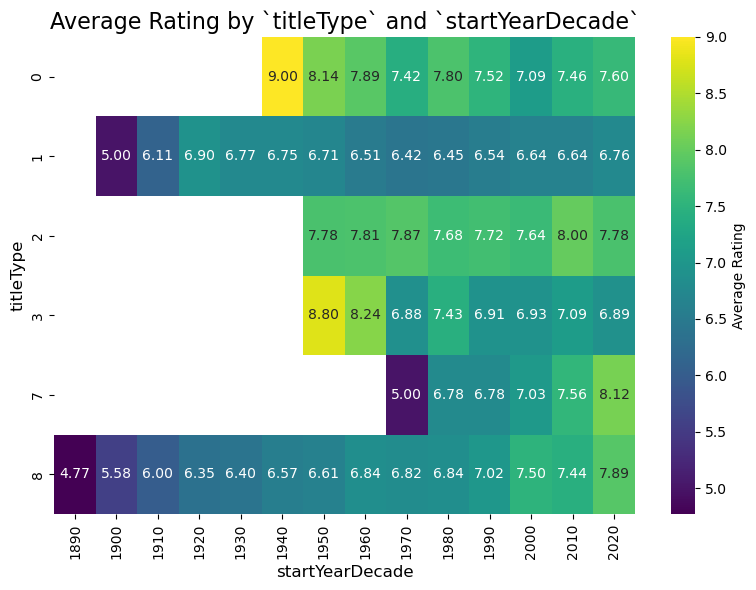

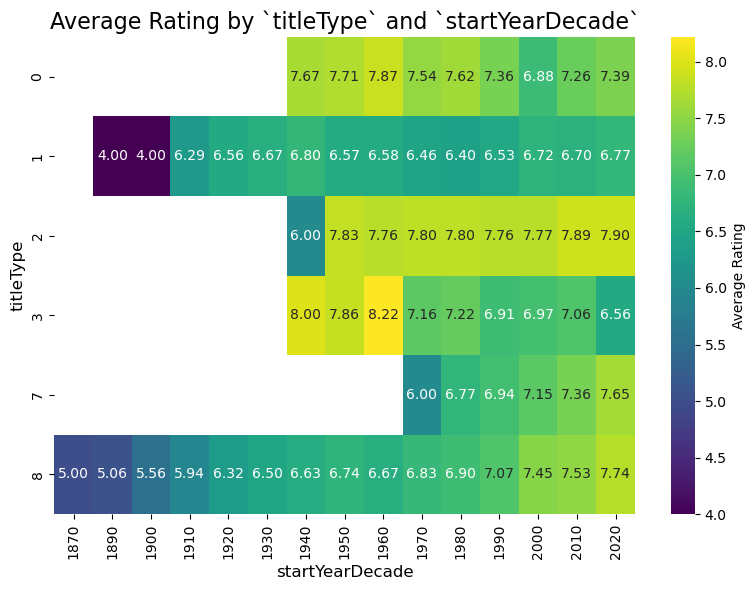

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_heatmap_rating_by_title_type_and_decade(data):
    """
    Creates a heatmap showing the average rating for combinations of titleType and startYear decade.

    Args:
        data (pd.DataFrame): The DataFrame containing the data with columns 'titleType', 'startYear', and 'rating'.
    """
    # Create a column to categorize 'startYear' into intervals (decades)
    data['startYearDecade'] = (data['startYear'] // 10) * 10

    # Calculate the average rating for combinations of titleType and decade
    heatmap_data = data.groupby(['titleType', 'startYearDecade'])['rating'].mean().unstack()

    # Create the heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        cbar_kws={'label': 'Average Rating'}
    )

    plt.title('Average Rating by `titleType` and `startYearDecade`', fontsize=16)
    plt.xlabel('startYearDecade', fontsize=12)
    plt.ylabel('titleType', fontsize=12)
    plt.tight_layout()
    plt.show()

# Example calls
plot_heatmap_rating_by_title_type_and_decade(data_train)
plot_heatmap_rating_by_title_type_and_decade(data_test)

/tmp/ipykernel_14669/209658965.py:17: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



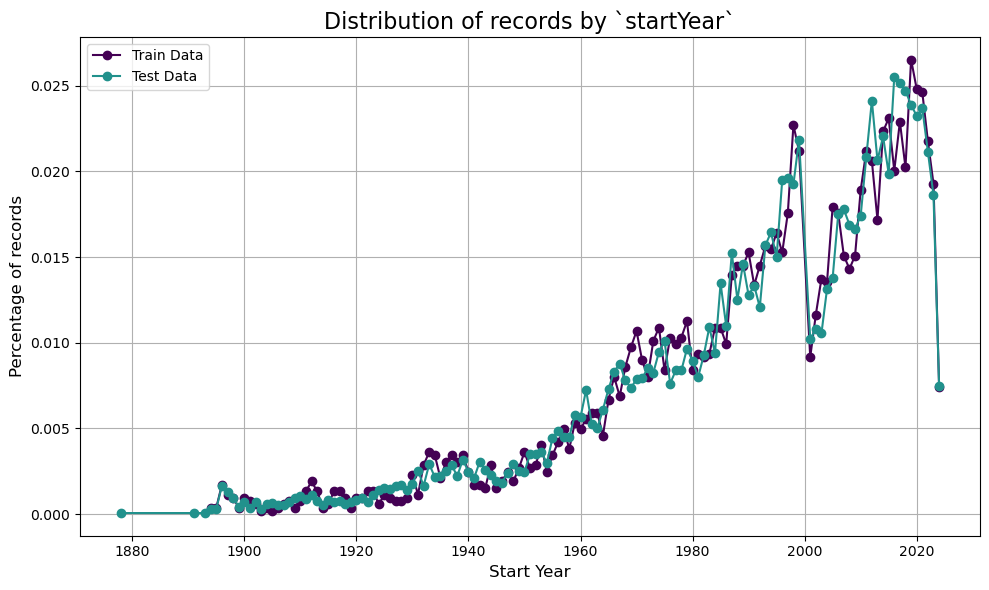

In [19]:
import matplotlib.cm as cm  # Importa cm da matplotlib


def plot_comparison_lineplot(data_train, data_test):
    """
    Creates a line plot showing the percentage of rows grouped by startYear, comparing data_train and data_test.

    Args:
        data_train (pd.DataFrame): The training dataset.
        data_test (pd.DataFrame): The test dataset.
    """
    # Calculate the percentage of rows for each startYear in both datasets
    train_counts = data_train['startYear'].value_counts(normalize=True).sort_index()
    test_counts = data_test['startYear'].value_counts(normalize=True).sort_index()

    # Create the line plot with the Viridis colormap
    viridis = cm.get_cmap('viridis', 3)  # Create a colormap with three colors

    plt.figure(figsize=(10, 6))
    plt.plot(train_counts.index, train_counts.values, marker='o', label='Train Data', color=viridis(0))
    plt.plot(test_counts.index, test_counts.values, marker='o', label='Test Data', color=viridis(1))
    plt.title('Distribution of records by `startYear`', fontsize=16)
    plt.xlabel('Start Year', fontsize=12)
    plt.ylabel('Percentage of records', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_comparison_lineplot(data_train, data_test)


/tmp/ipykernel_14669/460538405.py:18: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



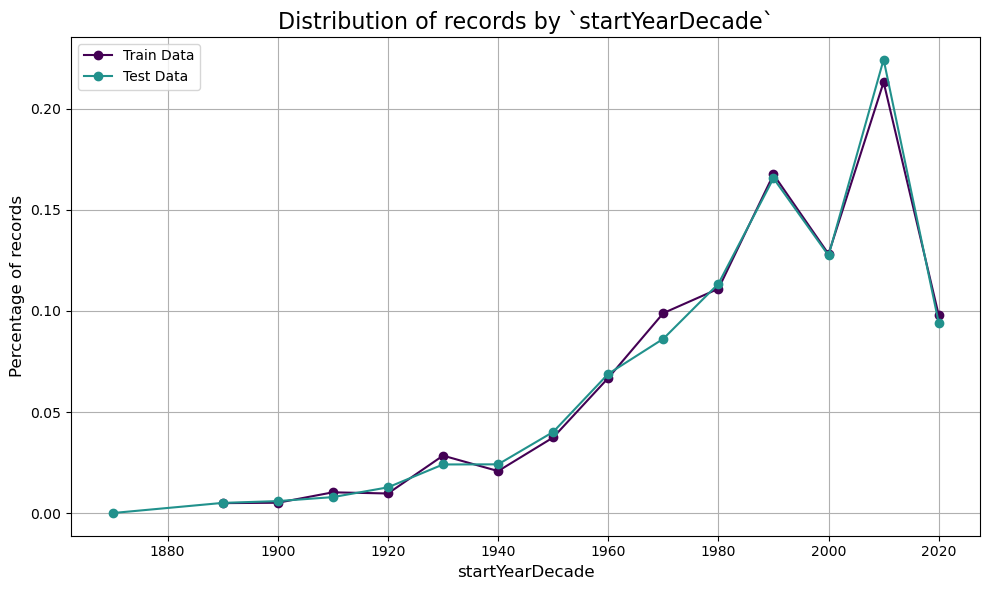

In [20]:
def plot_comparison_lineplot_decade(data_train, data_test):
    """
    Creates a line plot showing the percentage of rows grouped by startYearDecade, comparing data_train and data_test.

    Args:
        data_train (pd.DataFrame): The training dataset.
        data_test (pd.DataFrame): The test dataset.
    """
    # Create a column to categorize 'startYear' into intervals (decades)
    data_train['startYearDecade'] = (data_train['startYear'] // 10) * 10
    data_test['startYearDecade'] = (data_test['startYear'] // 10) * 10

    # Calculate the percentage of rows for each startYearDecade in both datasets
    train_counts = data_train['startYearDecade'].value_counts(normalize=True).sort_index()
    test_counts = data_test['startYearDecade'].value_counts(normalize=True).sort_index()

    # Create the line plot with the Viridis colormap
    viridis = cm.get_cmap('viridis', 3)  # Create a colormap with two colors

    plt.figure(figsize=(10, 6))
    plt.plot(train_counts.index, train_counts.values, marker='o', label='Train Data', color=viridis(0))
    plt.plot(test_counts.index, test_counts.values, marker='o', label='Test Data', color=viridis(1))

    plt.title('Distribution of records by `startYearDecade`', fontsize=16)
    plt.xlabel('startYearDecade', fontsize=12)
    plt.ylabel('Percentage of records', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_comparison_lineplot_decade(data_train, data_test)


In [21]:
def store_dataset(data, filename):
    
    file_path = f"{filename}.csv"
    data.to_csv(file_path, index=False)
    
    print(f"Dataset successfully stored as {file_path}")
    return file_path

test = store_dataset(data_test, 'data/output/01_data_understanding/data_train')
train = store_dataset(data_train, 'data/output/01_data_understanding/data_test')

Dataset successfully stored as data/output/01_data_understanding/data_train.csv
Dataset successfully stored as data/output/01_data_understanding/data_test.csv
